# Archaea specieswise optimization

Interactive notebook for running and diagnosing specieswise hierarchical-EB optimization on the AleRax Archaea dataset.

It exposes the pieces that matter for these runs: family selection, specieswise model construction, Pi/Neumann/self-loop-solver schedules, optimizer settings, checkpoint/resume, and plotting of loss, gradients, rates, and phase transitions.

## Safety defaults

The notebook is safe to execute top-to-bottom by default. It loads helper code and plots an existing result JSON if available, but it does **not** build the full GPU model or start optimization unless `BUILD_MODEL = True` and `RUN_OPTIMIZATION = True` in the configuration cell.

In [1]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
import importlib.util
import json
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

CWD = Path.cwd()
REPO = CWD if (CWD / "gpurec").exists() else CWD.parent if (CWD.parent / "gpurec").exists() else CWD
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from gpurec import GeneReconModel, SolverOptions, clamp_log_rate_

SCRIPT_PATH = REPO / "scripts/optimize_alerax_archaea_genewise_adam.py"
spec = importlib.util.spec_from_file_location("archaea_opt", SCRIPT_PATH)
archaea_opt = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(archaea_opt)

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True})
torch.set_float32_matmul_precision("high")

REPO

PosixPath('/home/enzo/Documents/git/gpurec/gpurec')

## Configuration

Edit this cell to choose a subset/full dataset, resume checkpoint, optimizer, and solver schedule. A schedule entry is:

```text
STEPS:PI_ITERS:NEUMANN_TERMS:DTYPE:SELF_LOOP_SOLVER:LR
```

`SELF_LOOP_SOLVER` is the backward/adjoint self-loop solver: `neumann` or `gmres`. It does not replace the normal forward likelihood solver.

In [2]:
DATA_ROOT = REPO / "tests/data/alerax_archaea_davin2017"
SPECIES_TREE = DATA_ROOT / "species_reference/reference_species_tree.newick"
FAMILY_DIR = DATA_ROOT / "ale_gene_tree_distributions/main_families_ge4seq"
RESULT_DIR = REPO / "output/alerax_archaea_genewise_adam"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Execution controls. Leave both False for a safe analysis-only execution.
BUILD_MODEL = True
RUN_OPTIMIZATION = True

# Use 0 for all eligible families. For interactive smoke tests, use e.g. 32, 64, or 256.
MAX_FAMILIES = 0
MIN_LEAVES = 4
FAMILY_ORDER = "smallest"  # smallest, largest, lexicographic
RECURSIVE_FAMILY_SEARCH = False

MODE = "specieswise"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 20260609

# Packing controls used for the whole archaeal dataset.
FAMILY_CHUNK_SIZE = 0
CLADE_BUDGET = 1_000_000
BATCH_PACKING = "depth_first_fit"
MAX_WAVE_SIZE = 8192

# Initialization. Set INIT_JSON to resume theta and EB hyperparameters.
THETA_INIT_RATE = 0.05
INIT_JSON = None
# Example:
# INIT_JSON = RESULT_DIR / "specieswise_complete_ccp_all_ge4_hier_eb_rprop_strongprior_fp32gmres_finish100_lr5e-5.json"

# Hierarchical EB controls.
HIERARCHICAL_EB = True
PRIOR_INITIAL_SIGMA = 0.5
PRIOR_MIN_SIGMA = 0.1
PRIOR_MU_SIGMA = 10.0
PRIOR_LOG_SIGMA_SIGMA = 0.02

# Rate bounds. Specieswise EB experiments so far used unbounded/unprojected rates.
UNBOUNDED_UNPROJECTED = True
MIN_RATE = 1e-10
MAX_RATE = 2.0
CLIP_GRAD_NORM = 200.0

# Optimizer controls.
OPTIMIZER = "rprop"  # adam, rmsprop, sgd, rprop, adadelta, adafactor, adamax
OPTIMIZER_LR = None  # if None, each schedule phase LR or optimizer default is used
OPTIMIZER_MOMENTUM = 0.0
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
RMSPROP_ALPHA = 0.99
ADADELTA_RHO = 0.9
OPTIMIZER_EPS = None
PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES = False

# LR shaping inside each phase. Use only ramp or decay, not both.
LR_RAMP_STEPS = 0
LR_RAMP_START_FACTOR = 0.25
LR_RAMP_FIRST_PHASE = False
LR_DECAY_STEPS = 0
LR_DECAY_END_FACTOR = 1.0

# Suggested editable schedule. Start cheap in fp32; reserve fp64+gmres for final checking.
SCHEDULE_TEXT = "80:8:8:float32:neumann:1.0,120:12:12:float32:neumann:0.1,160:16:16:float32:neumann:0.001"

# Solver controls outside the schedule.
E_MAX_ITER = 2000
E_TOL = 1e-8

# Convergence checks used when saving summaries.
TAIL_WINDOW = 40
TAIL_SLOPE_TOL = 0.02
MIN_IMPROVEMENT_BITS = 0.0
MAX_PROJECTED_GRAD_NORM = 0.05

OUTPUT_JSON = RESULT_DIR / "specieswise_notebook_run.json"

SCHEDULE = archaea_opt.parse_schedule(SCHEDULE_TEXT)
pd.DataFrame(SCHEDULE)

,steps,pi_iters,neumann_terms,dtype,self_loop_solver,optimizer_lr
0,80,8,8,float32,neumann,1.000
1,120,12,12,float32,neumann,0.100
2,160,16,16,float32,neumann,0.001


## Build arguments and select families

In [3]:
def make_args() -> SimpleNamespace:
    return SimpleNamespace(
        mode=MODE,
        init_json=INIT_JSON,
        theta_init_rate=THETA_INIT_RATE,
        min_rate=MIN_RATE,
        max_rate=MAX_RATE,
        unbounded_unprojected=UNBOUNDED_UNPROJECTED,
        clip_grad_norm=CLIP_GRAD_NORM,
        optimizer=OPTIMIZER,
        optimizer_lr=OPTIMIZER_LR,
        adam_lr=None,
        optimizer_momentum=OPTIMIZER_MOMENTUM,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        rmsprop_alpha=RMSPROP_ALPHA,
        adadelta_rho=ADADELTA_RHO,
        optimizer_eps=OPTIMIZER_EPS,
        preserve_optimizer_state_across_phases=PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES,
        lr_ramp_steps=LR_RAMP_STEPS,
        lr_ramp_start_factor=LR_RAMP_START_FACTOR,
        lr_ramp_first_phase=LR_RAMP_FIRST_PHASE,
        lr_decay_steps=LR_DECAY_STEPS,
        lr_decay_end_factor=LR_DECAY_END_FACTOR,
        hierarchical_eb=HIERARCHICAL_EB,
        prior_initial_sigma=PRIOR_INITIAL_SIGMA,
        prior_min_sigma=PRIOR_MIN_SIGMA,
        prior_mu_sigma=PRIOR_MU_SIGMA,
        prior_log_sigma_sigma=PRIOR_LOG_SIGMA_SIGMA,
    )


args = make_args()
torch.manual_seed(SEED)

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA requested but torch.cuda.is_available() is false")

ale_families, selection = archaea_opt.select_families(
    FAMILY_DIR,
    max_families=MAX_FAMILIES,
    family_order=FAMILY_ORDER,
    min_leaves=MIN_LEAVES,
    recursive=RECURSIVE_FAMILY_SEARCH,
)

pd.Series(selection)

candidate_families           5446
excluded_below_min_leaves      67
eligible_families            5379
selected_families            5379
dtype: int64

## Initialize or resume the model

Set `BUILD_MODEL = True` in the configuration cell before running this cell if you want to allocate the GPU model.

In [4]:
state = None

def initialize_state() -> dict:
    clade_budget = None if CLADE_BUDGET == 0 else CLADE_BUDGET
    first_phase = SCHEDULE[0]
    solver_options = SolverOptions(
        e_init=-1000.0,
        e_max_iter=E_MAX_ITER,
        e_tol=E_TOL,
        pi_iters=int(first_phase["pi_iters"]),
        neumann_terms=int(first_phase["neumann_terms"]),
        self_loop_solver=str(first_phase["self_loop_solver"]),
    )
    model = GeneReconModel(
        SPECIES_TREE,
        ale_families,
        mode=MODE,
        device=DEVICE,
        family_chunk_size=FAMILY_CHUNK_SIZE,
        clade_budget=clade_budget,
        batch_packing=BATCH_PACKING,
        max_wave_size=MAX_WAVE_SIZE,
        solver_options=solver_options,
    )
    current_dtype_name = str(first_phase["dtype"])
    model.to(dtype=archaea_opt.torch_dtype(current_dtype_name))
    model.receiver_weights.requires_grad_(False)
    use_rate_bounds = not bool(UNBOUNDED_UNPROJECTED)
    with torch.no_grad():
        model.theta.fill_(math.log2(THETA_INIT_RATE))
        if use_rate_bounds:
            clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
        model.clear_warm_starts()

    prior = archaea_opt.initialize_hierarchical_prior(args, model.theta)
    archaea_opt.load_initial_state_(args, model=model, hierarchical_prior=prior)
    params = [model.theta, *archaea_opt.hierarchical_prior_parameters(prior)]
    base_lr = archaea_opt.optimizer_lr(args)
    current_lr = float(first_phase["optimizer_lr"] or base_lr)
    optimizer = archaea_opt.make_optimizer(params, args, current_lr)

    return {
        "model": model,
        "prior": prior,
        "optimizer": optimizer,
        "optimizer_params": params,
        "base_lr": base_lr,
        "current_lr": current_lr,
        "current_dtype_name": current_dtype_name,
        "history": [],
        "global_step": 0,
        "use_rate_bounds": use_rate_bounds,
        "t0": time.perf_counter(),
    }


if BUILD_MODEL:
    state = initialize_state()
    print("Model initialized", {"theta_shape": tuple(state["model"].theta.shape), "dtype": state["current_dtype_name"]})
else:
    print("BUILD_MODEL is False. Set it to True to allocate the GPU model.")

Model initialized {'theta_shape': (119, 3), 'dtype': 'float32'}


## Optimization loop

This loop mirrors the standalone script but leaves the state in memory so you can inspect, plot, adjust the schedule, and continue.

In [5]:
def _set_optimizer_lr(optimizer, lr: float) -> None:
    for group in optimizer.param_groups:
        group["lr"] = lr


def _loss_backward(state: dict, *, step_label: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, dict[str, float]]:
    model = state["model"]
    prior = state["prior"]
    optimizer = state["optimizer"]
    optimizer.zero_grad(set_to_none=True)
    data_loss = model()
    prior_loss = archaea_opt.hierarchical_prior_bits(model.theta, prior, args)
    loss = data_loss + prior_loss
    if not torch.isfinite(loss).item():
        raise FloatingPointError(f"non-finite loss at step {step_label}: total={loss} data={data_loss} prior={prior_loss}")
    loss.backward()
    if model.theta.grad is None or not torch.isfinite(model.theta.grad).all().item():
        raise FloatingPointError(f"non-finite theta gradient at step {step_label}")

    prior_params = archaea_opt.hierarchical_prior_parameters(prior)
    metrics = {
        "raw_grad_norm": float(model.theta.grad.detach().norm().cpu()),
        "prior_grad_norm": archaea_opt.gradient_norm(prior_params),
        "joint_grad_norm": archaea_opt.gradient_norm([model.theta, *prior_params]),
    }
    if state["use_rate_bounds"]:
        from gpurec import project_rate_gradient_
        project_rate_gradient_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
    metrics["projected_grad_norm"] = float(model.theta.grad.detach().norm().cpu())
    if CLIP_GRAD_NORM > 0.0:
        torch.nn.utils.clip_grad_norm_([model.theta, *prior_params], CLIP_GRAD_NORM)
    metrics["clipped_grad_norm"] = float(model.theta.grad.detach().norm().cpu())
    metrics["clipped_prior_grad_norm"] = archaea_opt.gradient_norm(prior_params)
    metrics["clipped_joint_grad_norm"] = archaea_opt.gradient_norm([model.theta, *prior_params])
    return loss, data_loss, prior_loss, metrics


def run_schedule(state: dict, schedule: list[dict], *, print_every: int = 10) -> dict:
    model = state["model"]
    prior = state["prior"]
    for phase_index, phase in enumerate(schedule):
        phase_steps = int(phase["steps"])
        phase_dtype_name = str(phase["dtype"])
        phase_target_lr = float(phase["optimizer_lr"] or state["base_lr"])
        model.configure_solver(
            pi_iters=int(phase["pi_iters"]),
            neumann_terms=int(phase["neumann_terms"]),
            self_loop_solver=str(phase["self_loop_solver"]),
        )
        optimizer_reset = False
        if phase_dtype_name != state["current_dtype_name"]:
            model.to(dtype=archaea_opt.torch_dtype(phase_dtype_name))
            state["current_dtype_name"] = phase_dtype_name
            archaea_opt.move_hierarchical_prior_(prior, dtype=archaea_opt.torch_dtype(phase_dtype_name), device=model.theta.device)
            state["optimizer_params"] = [model.theta, *archaea_opt.hierarchical_prior_parameters(prior)]
            state["optimizer"] = archaea_opt.make_optimizer(state["optimizer_params"], args, phase_target_lr)
            state["current_lr"] = phase_target_lr
            optimizer_reset = True
        elif phase_index > 0 and not PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES:
            state["optimizer"] = archaea_opt.make_optimizer(state["optimizer_params"], args, phase_target_lr)
            state["current_lr"] = phase_target_lr
            optimizer_reset = True
        elif phase_target_lr != state["current_lr"]:
            _set_optimizer_lr(state["optimizer"], phase_target_lr)
            state["current_lr"] = phase_target_lr

        model.clear_warm_starts()
        for phase_step in range(phase_steps):
            step_lr = archaea_opt.scheduled_step_lr(phase_target_lr, phase_step=phase_step, phase_index=phase_index, args=args)
            if step_lr != state["current_lr"]:
                _set_optimizer_lr(state["optimizer"], step_lr)
                state["current_lr"] = step_lr
            archaea_opt.sync(torch.device(DEVICE))
            step_t0 = time.perf_counter()
            loss, data_loss, prior_loss, grad_metrics = _loss_backward(state, step_label=state["global_step"])
            state["optimizer"].step()
            if state["use_rate_bounds"]:
                clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
            archaea_opt.sync(torch.device(DEVICE))

            row = {
                "step": state["global_step"],
                "phase": phase_index,
                "phase_step": phase_step,
                "optimizer": OPTIMIZER,
                "optimizer_lr": state["current_lr"],
                "optimizer_target_lr": phase_target_lr,
                "optimizer_reset_at_phase_start": optimizer_reset,
                "pi_iters": int(phase["pi_iters"]),
                "neumann_terms": int(phase["neumann_terms"]),
                "self_loop_solver": str(phase["self_loop_solver"]),
                "dtype": phase_dtype_name,
                "loss_bits": float(loss.detach().cpu()),
                "data_loss_bits": float(data_loss.detach().cpu()),
                "prior_loss_bits": float(prior_loss.detach().cpu()),
                **grad_metrics,
                "step_s": time.perf_counter() - step_t0,
                **archaea_opt.theta_stats(model.theta),
                **archaea_opt.hierarchical_prior_stats(prior, args),
            }
            state["history"].append(row)
            if state["global_step"] == 0 or (state["global_step"] + 1) % print_every == 0:
                print(
                    f"step={state['global_step'] + 1:04d} phase={phase_index} "
                    f"pi={phase['pi_iters']} neumann={phase['neumann_terms']} solver={phase['self_loop_solver']} "
                    f"dtype={phase_dtype_name} lr={state['current_lr']:.4g} "
                    f"loss={row['loss_bits']:.6f} data={row['data_loss_bits']:.6f} prior={row['prior_loss_bits']:.6f} "
                    f"grad={row['joint_grad_norm']:.3g} rate=[{row['rate_min']:.3g},{row['rate_max']:.3g}] "
                    f"step_s={row['step_s']:.3f}",
                    flush=True,
                )
            state["global_step"] += 1
    return state


if RUN_OPTIMIZATION:
    if state is None:
        raise RuntimeError("Set BUILD_MODEL=True and run the model initialization cell before optimization.")
    state = run_schedule(state, SCHEDULE, print_every=10)
else:
    print("RUN_OPTIMIZATION is False. Set it to True to run the configured schedule.")

step=0001 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=422752.250000 data=423109.250000 prior=-357.000031 grad=2.88e+03 rate=[0.025,0.1] step_s=1.660
step=0010 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=362071.812500 data=359547.750000 prior=2524.053467 grad=1.98e+03 rate=[0.0054,9.34] step_s=0.658
step=0020 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=359225.250000 data=357032.562500 prior=2192.686768 grad=254 rate=[0.0104,7.08] step_s=0.677
step=0030 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=359028.312500 data=356797.562500 prior=2230.746094 grad=81.7 rate=[0.0095,7.4] step_s=0.698
step=0040 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=358931.593750 data=356657.500000 prior=2274.092529 grad=73.4 rate=[0.00945,8.81] step_s=0.682
step=0050 phase=0 pi=8 neumann=8 solver=neumann dtype=float32 lr=1 loss=358838.562500 data=356541.437500 prior=2297.133301 grad=76.5 rate=[0.00949,11.1] step_s=0.668
step

## Plotting helpers

Use these on the in-memory `state['history']` after a run, or on a loaded JSON history.

steps                          360.000000
initial_loss_bits           422752.250000
final_loss_bits             357178.250000
improvement_bits             65574.000000
tail_slope_bits_per_step        -2.511424
final_joint_grad_norm          111.085551
final_rate_min                   0.008809
final_rate_max                 876.084473
median_step_s_post_first         0.825765
dtype: float64

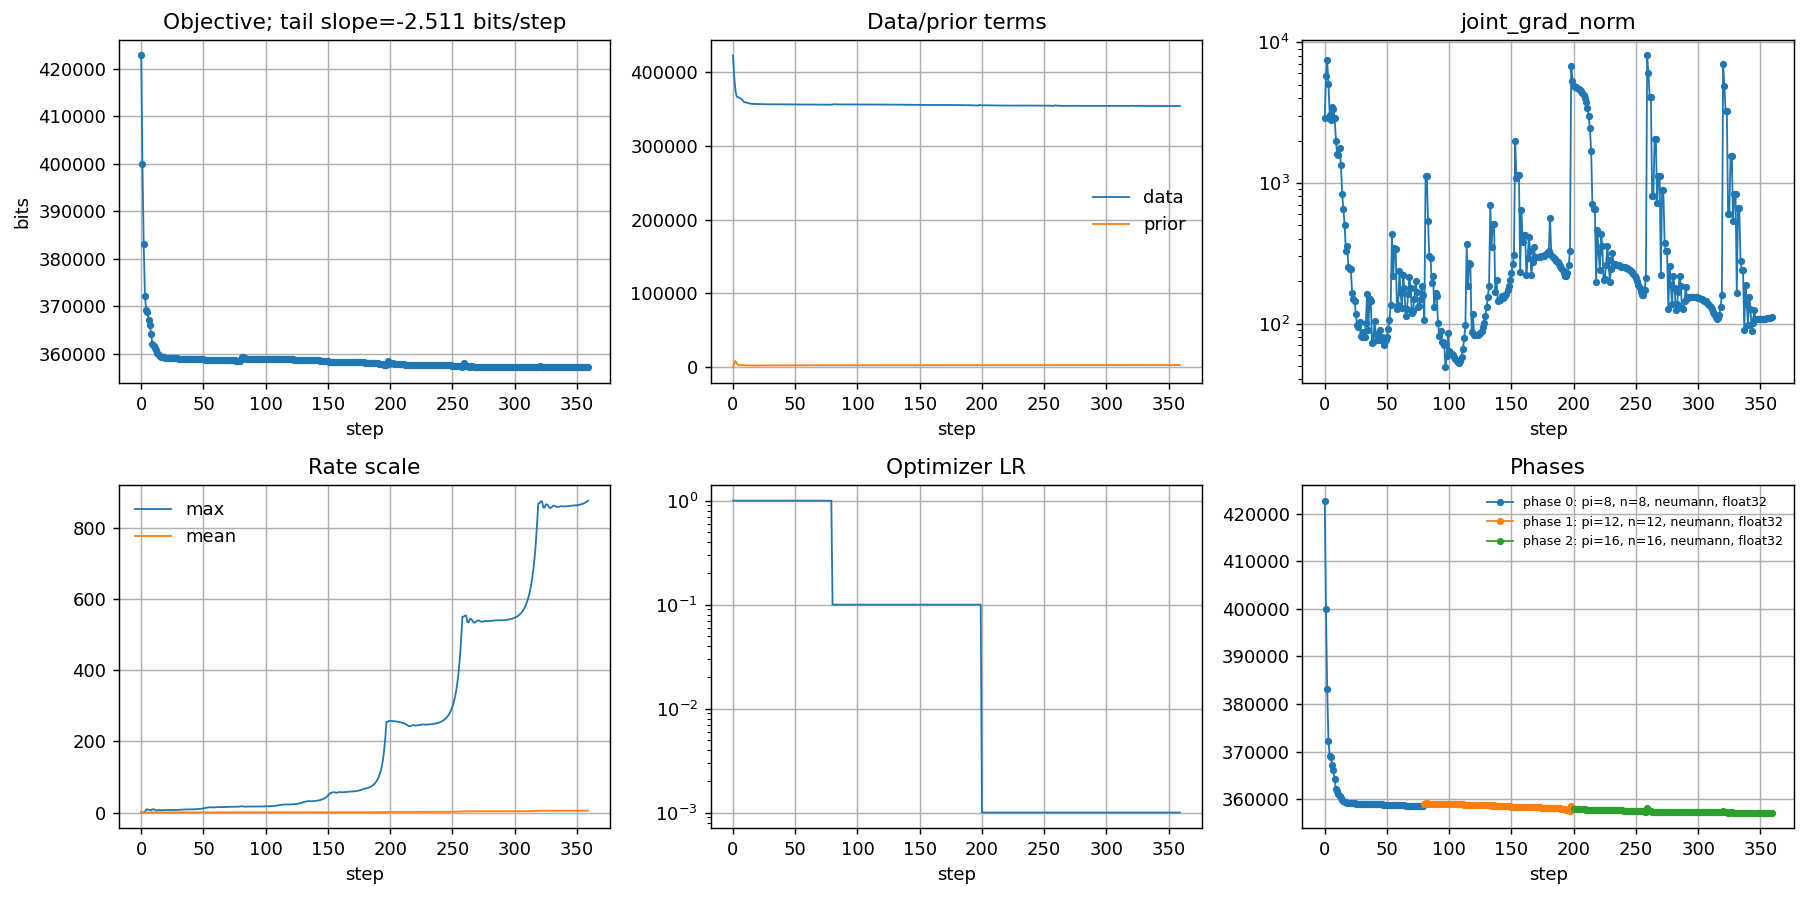

In [6]:
def history_frame(history: list[dict]) -> pd.DataFrame:
    if not history:
        return pd.DataFrame()
    df = pd.DataFrame(history).copy()
    df["loss_delta_from_start"] = df["loss_bits"] - df["loss_bits"].iloc[0]
    if len(df) >= 2:
        df["step_loss_delta"] = df["loss_bits"].diff()
    return df


def tail_slope(values, window=40) -> float:
    values = np.asarray(values, dtype=float)
    if values.size < 2:
        return 0.0
    tail = values[-min(window, values.size):]
    x = np.arange(tail.size, dtype=float)
    return float(np.polyfit(x, tail, 1)[0])


def plot_history(history: list[dict], *, tail_window: int = 40):
    df = history_frame(history)
    if df.empty:
        print("No history to plot.")
        return None

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    ax = axes[0, 0]
    ax.plot(df["step"], df["loss_bits"], marker=".", linewidth=1)
    ax.set_title(f"Objective; tail slope={tail_slope(df['loss_bits'], tail_window):.4g} bits/step")
    ax.set_xlabel("step")
    ax.set_ylabel("bits")

    ax = axes[0, 1]
    ax.plot(df["step"], df["data_loss_bits"], label="data", linewidth=1)
    ax.plot(df["step"], df["prior_loss_bits"], label="prior", linewidth=1)
    ax.set_title("Data/prior terms")
    ax.set_xlabel("step")
    ax.legend(frameon=False)

    ax = axes[0, 2]
    grad_col = "joint_grad_norm" if "joint_grad_norm" in df else "projected_grad_norm"
    ax.plot(df["step"], df[grad_col], marker=".", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(grad_col)
    ax.set_xlabel("step")

    ax = axes[1, 0]
    ax.plot(df["step"], df["rate_max"], label="max", linewidth=1)
    ax.plot(df["step"], df["rate_mean"], label="mean", linewidth=1)
    ax.set_title("Rate scale")
    ax.set_xlabel("step")
    ax.legend(frameon=False)

    ax = axes[1, 1]
    ax.plot(df["step"], df["optimizer_lr"], linewidth=1)
    ax.set_yscale("log")
    ax.set_title("Optimizer LR")
    ax.set_xlabel("step")

    ax = axes[1, 2]
    for phase, group in df.groupby("phase"):
        label = f"phase {phase}: pi={group['pi_iters'].iloc[0]}, n={group['neumann_terms'].iloc[0]}, {group['self_loop_solver'].iloc[0]}, {group['dtype'].iloc[0]}"
        ax.plot(group["step"], group["loss_bits"], marker=".", linewidth=1, label=label)
    ax.set_title("Phases")
    ax.set_xlabel("step")
    ax.legend(frameon=False, fontsize=7)

    fig.tight_layout()
    return fig


def summarize_history(history: list[dict], *, tail_window: int = 40) -> pd.Series:
    df = history_frame(history)
    if df.empty:
        return pd.Series(dtype=float)
    last = df.iloc[-1]
    return pd.Series({
        "steps": len(df),
        "initial_loss_bits": df["loss_bits"].iloc[0],
        "final_loss_bits": last["loss_bits"],
        "improvement_bits": df["loss_bits"].iloc[0] - last["loss_bits"],
        "tail_slope_bits_per_step": tail_slope(df["loss_bits"], tail_window),
        "final_joint_grad_norm": last.get("joint_grad_norm", last.get("projected_grad_norm")),
        "final_rate_min": last["rate_min"],
        "final_rate_max": last["rate_max"],
        "median_step_s_post_first": df["step_s"].iloc[1:].median() if len(df) > 1 else df["step_s"].iloc[0],
    })


if state is not None and state["history"]:
    display(summarize_history(state["history"], tail_window=TAIL_WINDOW))
    plot_history(state["history"], tail_window=TAIL_WINDOW)
else:
    print("No in-memory run history yet.")

## Save a checkpoint JSON

Run this after optimization to save a script-compatible checkpoint. You can later set `INIT_JSON` to this file and continue.

In [7]:
def checkpoint_payload(state: dict) -> dict:
    history = state["history"]
    try:
        convergence = archaea_opt.assert_converged(
            history,
            tail_window=TAIL_WINDOW,
            tail_slope_tol=TAIL_SLOPE_TOL,
            min_improvement_bits=MIN_IMPROVEMENT_BITS,
            max_projected_grad_norm=MAX_PROJECTED_GRAD_NORM,
        )
        convergence["converged"] = True
        convergence_error = None
    except RuntimeError as exc:
        convergence = archaea_opt.summarize_history(history, tail_window=min(TAIL_WINDOW, len(history)))
        convergence["converged"] = False
        convergence_error = str(exc)

    return {
        "species_tree": str(SPECIES_TREE),
        "family_dir": str(FAMILY_DIR),
        "families": [str(path) for path in ale_families],
        "family_input": "ALE complete CCP files",
        "min_leaves": MIN_LEAVES,
        "recursive_family_search": RECURSIVE_FAMILY_SEARCH,
        "selection": selection,
        "mode": MODE,
        "device": DEVICE,
        "optimizer": archaea_opt.optimizer_options(args, state["base_lr"]),
        "optimizer_phase_controls": {
            "reset_optimizer_state_across_phases": not PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES,
            "lr_ramp_steps": LR_RAMP_STEPS,
            "lr_ramp_start_factor": LR_RAMP_START_FACTOR,
            "lr_ramp_first_phase": LR_RAMP_FIRST_PHASE,
            "lr_decay_steps": LR_DECAY_STEPS,
            "lr_decay_end_factor": LR_DECAY_END_FACTOR,
        },
        "use_rate_bounds": state["use_rate_bounds"],
        "hierarchical_eb": HIERARCHICAL_EB,
        "hierarchical_prior": {
            "initial_sigma": PRIOR_INITIAL_SIGMA,
            "min_sigma": PRIOR_MIN_SIGMA,
            "mu_sigma": PRIOR_MU_SIGMA,
            "log_sigma_sigma": PRIOR_LOG_SIGMA_SIGMA,
            "row_count": state["prior"]["row_count"],
            **archaea_opt.hierarchical_prior_stats(state["prior"], args),
        } if state["prior"] is not None else None,
        "clip_grad_norm": CLIP_GRAD_NORM,
        "clade_budget": None if CLADE_BUDGET == 0 else CLADE_BUDGET,
        "schedule": SCHEDULE,
        "solver_options": {
            "e_max_iter": E_MAX_ITER,
            "e_tol": E_TOL,
            "self_loop_solver": state["model"].solver_options.self_loop_solver,
        },
        "final_theta": archaea_opt.theta_values(state["model"].theta),
        "convergence": convergence,
        "convergence_error": convergence_error,
        "elapsed_s": time.perf_counter() - state["t0"],
        "history": history,
        "backtracking": [],
    }


if state is not None and state["history"]:
    payload = checkpoint_payload(state)
    OUTPUT_JSON.write_text(json.dumps(payload, indent=2) + "\n", encoding="utf-8")
    print("wrote", OUTPUT_JSON)
else:
    print("No in-memory run to save yet.")

wrote /home/enzo/Documents/git/gpurec/gpurec/output/alerax_archaea_genewise_adam/specieswise_notebook_run.json


## Load and plot an existing result JSON

This lets the notebook act as a dashboard for runs launched from the standalone script.

steps                          100.000000
initial_loss_bits           359061.781250
final_loss_bits             359030.531250
improvement_bits                31.250000
tail_slope_bits_per_step        -0.440411
final_joint_grad_norm           12.582396
final_rate_min                   0.009396
final_rate_max                  19.652981
median_step_s_post_first         1.940939
dtype: float64

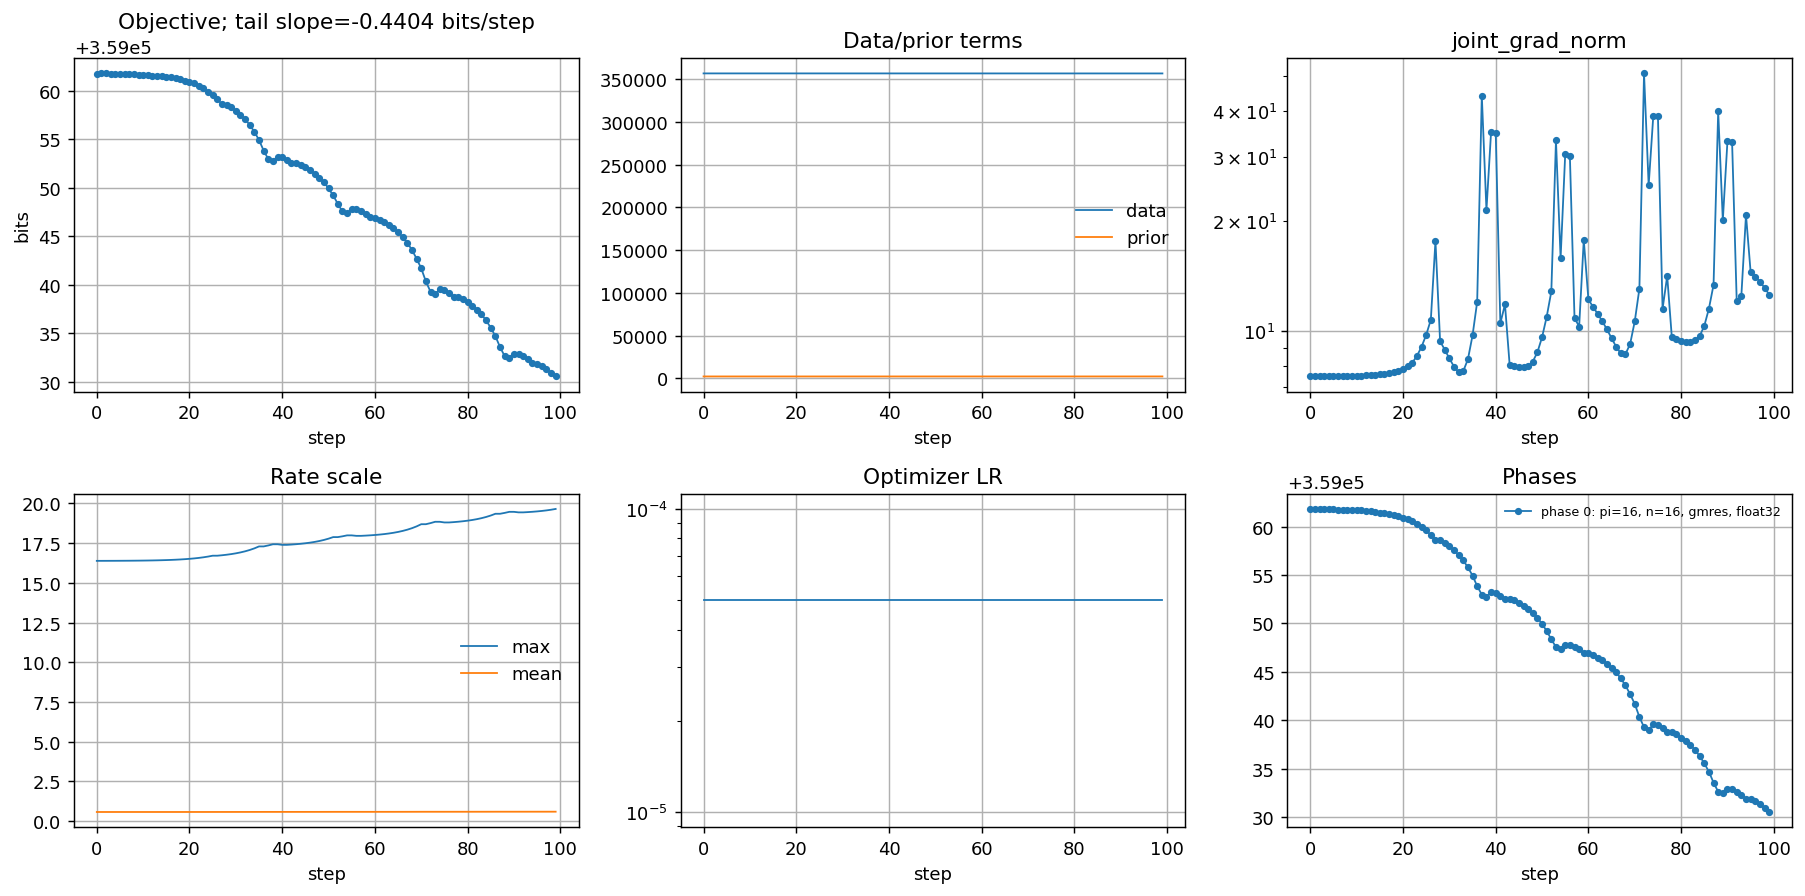

In [8]:
EXISTING_JSON = RESULT_DIR / "specieswise_complete_ccp_all_ge4_hier_eb_rprop_strongprior_fp32gmres_finish100_lr5e-5.json"

if EXISTING_JSON.exists():
    existing_payload = json.loads(EXISTING_JSON.read_text())
    existing_history = existing_payload["history"]
    display(summarize_history(existing_history, tail_window=min(TAIL_WINDOW, len(existing_history))))
    plot_history(existing_history, tail_window=min(TAIL_WINDOW, len(existing_history)))
else:
    print("No existing JSON found at", EXISTING_JSON)

## Inspect final specieswise rates

The preprocessor currently exposes species/node row ids, not original labels. This table lists the largest species-row/rate coordinates from a saved result.

In [9]:
if 'existing_payload' in globals() and "final_theta" in existing_payload:
    rates = np.asarray(existing_payload["final_theta"]["rates"], dtype=float)
    theta = np.asarray(existing_payload["final_theta"]["theta"], dtype=float)
    flat = rates.reshape(-1)
    print("rate quantiles", {q: float(np.quantile(flat, q)) for q in [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]})
    names = np.array(["D", "T", "L"])
    rows = []
    for idx in np.argsort(flat)[::-1][:15]:
        species_row = int(idx // 3)
        rate_col = int(idx % 3)
        rows.append({
            "species_node_row": species_row,
            "rate": names[rate_col],
            "value": rates[species_row, rate_col],
            "theta_log2": theta[species_row, rate_col],
        })
    display(pd.DataFrame(rows))
else:
    print("Load a result JSON with final_theta first.")

rate quantiles {0: 0.009395777247846127, 0.25: 0.052301522344350815, 0.5: 0.1367715299129486, 0.75: 0.4877057373523712, 0.9: 1.4097714900970462, 0.95: 2.346079015731809, 0.99: 5.711331157684324, 1.0: 19.652978897094727}


,species_node_row,rate,value,theta_log2
0,2,T,19.652979,4.296676
1,2,D,18.148523,4.181780
2,78,T,7.738021,2.951965
3,77,T,6.384170,2.674499
4,62,T,5.182672,2.373696
5,91,T,5.010468,2.324945
6,62,D,4.664424,2.221699
7,3,T,3.892579,1.960726
8,96,T,3.158963,1.659451
9,107,T,3.110612,1.637198


## Practical workflow

1. Start with a small `MAX_FAMILIES` smoke test and `BUILD_MODEL=True`, `RUN_OPTIMIZATION=True`.
2. Move to `MAX_FAMILIES=0` for the full 5,379-family specieswise run.
3. Do most optimization cheaply in `float32`, usually with truncated Neumann first.
4. Use the plots to watch the loss tail and joint gradient. Do not switch to final `float64` just because a fixed step count ended.
5. Once the fp32 tail is close to flat, run a short `float64:gmres` phase as a refinement/accuracy check and save a final checkpoint.